# Question 5

## Problem Statement

Calculate the specific volume of chlorine at $T = 460\ \text{K}$ and $P = 15\ \text{atm}$ using the
**Redlich-Kwong equation of state**:

$$
    P = \frac{RT}{v-b} - \frac{a}{\sqrt{T}\, v(v+b)}
$$

where

$$
    a = \frac{0.4278\, R^2 T_c^{2.5}}{P_c}, \qquad
    b = \frac{0.0867\, R\, T_c}{P_c}
$$

Take the ideal-gas volume as the initial guess, $P_c = 76.1\ \text{atm}, T_c = 417\ \text{K}$.

**Use the Newton-Raphson technique for obtaining the root.**


\newpage

## Analysis

- Newton-Raphson method iteratively determines the root of a function by moving a guess closer to the root with the help of its derivative.
- At every guess $v_n$, we find the slope of the tangent line, and a point that lies on the x-axis, $v_{n+1}$: $$f'(v_n) = \frac{f(v_n) - 0}{v_n - v_{n+1}} \implies v_{n+1} = v_n - \frac{f(v_n)}{f'(v_n)}$$
- To use in the Redlich-Kwong equation, we define the function $f(v)$ as: $$ f(v) = P - \frac{RT}{v-b} + \frac{a}{\sqrt{T}\, v(v+b)} $$ thus this gives us the derivative: $$ f'(v) = \frac{RT}{(v-b)^2} - \frac{a}{\sqrt{T}} \left( \frac{1}{v^2(v+b)} + \frac{1}{v(v+b)^2} \right)$$ $$ \implies f'(v) = \frac{RT}{(v-b)^2} - \frac{a(2v + b)}{\sqrt{T}\, v^2 (v+b)^2} $$
- Until we reach a stopping criteria, we keep updating the guess with the above formula.
    - If the criteria is a maximum number of iterations, we stop after that many iterations.
    - If the criteria is a tolerance factor, we stop when the difference between two consecutive guesses is less than the tolerance factor: $$ |x_{n+1} - x_n| < \epsilon $$

\newpage

## Algorithm

- **Step 01.** **START**
- **Step 02.** Inputs:

| Variable   | Description                     |
| ---------- | ------------------------------- |
| $f$        | Function whose root is required |
| $f'$       | Derivative of $f$               |
| $v^0$      | Initial guess                   |
| $k_max$    | Maximum iterations              |
| $\epsilon$ | Tolerance                       |

- **Step 03.** Initialize:

| Variable    | Description |
| ----------- | ----------- |
| $k$         | $1$         |
| $v^{(k)}$   | $v^0$       |
| $v^{(k+1)}$ | $\infty$    |

- **Step 04.** Repeat until $k \ge k_{\max}$ or $\|v^{(k+1)} - v^{(k)}\| < \epsilon$:
  - **Step 05.** Update current_guess $v^{(k)} = v^{(k+1)}$
  - **Step 06.** Update $v^{(k+1)}$ using the formula:
    $$
        v^{(k+1)} = v^{(k)} - \frac{f\!\left(v^{(k)}\right)}{f'\!\left(v^{(k)}\right)}
    $$
  - **Step 07.** Increment iteration_count $k = k + 1$
- **Step 08.** End repeat {**Step 04**}
- **Step 09.** Output: Final guess $v^{(k+1)}$
- **Step 10.** **STOP**


## Implementation

In [ ]:
%%file newtonraphson.m
function [final_guess, converged, guess_history] = ...
    newtonraphson(f, df, x0, epsilon, k_max) %#ok<FNDEF>

% @parameter f: function handle, f(v) = 0 defines the root to be found
% @parameter df: function handle, analytical derivative of f
% @parameter x0: initial guess (scalar)
% @parameter epsilon: tolerance factor for convergence
% @parameter k_max: maximum number of iterations

% @return final_guess: final guess vector after convergence
% @return converged: shows if convergence was achieved
% @return guess_history: history of guesses

if nargin < 5; k_max = 100; end
if nargin < 4; epsilon = 1e-6; end

k = 1; current_guess = x0; new_guess = inf;
guess_history = zeros(k_max, 1);
guess_history(1) = x0;

convergence_criteria_met = @(current_guess, new_guess) ...
    abs(new_guess - current_guess) < epsilon;
stopping_criteria_met = @(iter, current_guess, new_guess) ...
    iter >= k_max || convergence_criteria_met(current_guess, new_guess);

while ~stopping_criteria_met(k, current_guess, new_guess)
    if k > 1; current_guess = new_guess; end
    
    new_guess = current_guess - f(current_guess) / df(current_guess);
    fprintf("(%d) v: %.6f, f(v): %.6e\n", k, new_guess, f(new_guess));
    
    k = k + 1;
    guess_history(k) = new_guess;
end % end iterating with guess in kth place

final_guess = new_guess;
converged = convergence_criteria_met(current_guess, new_guess);
guess_history = guess_history(1:k);

end

## Results

We use this implementation on our given data to solve this question. The initial data given in the problem statement is stored in an input file as shown here:

```yaml
R: 8.314 m^{3}.Pa.K^{-1}.mol^{-1}
T: 460 K
P: 15 atm
T_{0}: 417 K
P_{0}: 76.1 atm
```

In [2]:
fprintf("--- INPUT ---\n");
file = fopen("input.txt", "r");
while ~feof(file); line = fgetl(file);
    tokens = regexp(line, "^([A-Za-z0-9_{}]+):\s*([\d.-]+)", "tokens");
    if ~isempty(tokens)
        value = str2double(tokens{1}{2});
        switch tokens{1}{1}
            case 'R', R = value;
            case 'T', T = value;
            case 'P', P = value;
            case 'T_{0}', T0 = value;
            case 'P_{0}', P0 = value;
        end
    end
end; fclose(file);

a = 0.4278 * R^2 * T0^2.5 / P0;
b = 0.0867 * R * T0 / P0;
v0 = R * T / P;
display_input = table(R, T, P, T0, P0, a, b, v0, ...
    VariableNames={'R', 'T', 'P', 'T_i', 'P_i', 'a', 'b', 'v_i'});
disp(display_input);

f = @(v) (R * T)./(v - b) - a./(sqrt(T) .* v .* (v + b)) - P;
df = @(v) -(R * T)./(v - b).^2 ...
    + a .* (2 .* v + b)./(sqrt(T) .* v.^2 .* (v + b).^2);

fprintf("--- OUTPUT ---\n");
[final_guess, converged, guess_history] = newtonraphson(f, df, v0);
fprintf("\nFinal guess: %.6f\n", final_guess);
fprintf("Converged: %s\n", string(converged));

--- INPUT ---
      R       T     P     T_i    P_i         a           b        v_i  
    _____    ___    __    ___    ____    __________    ______    ______

    8.314    460    15    417    76.1    1.3798e+06    3.9498    254.96

--- OUTPUT ---
(1) v: 241.057603, f(v): 4.026991e-02
(2) v: 241.739432, f(v): 1.073660e-04
(3) v: 241.741260, f(v): 7.672885e-10
(4) v: 241.741260, f(v): 0.000000e+00

Final guess: 241.741260
Converged: true


## Graph

We can visualize how quickly the Newton-Raphson method converges to the root by plotting the difference between two consecutive guesses against the number of iterations.

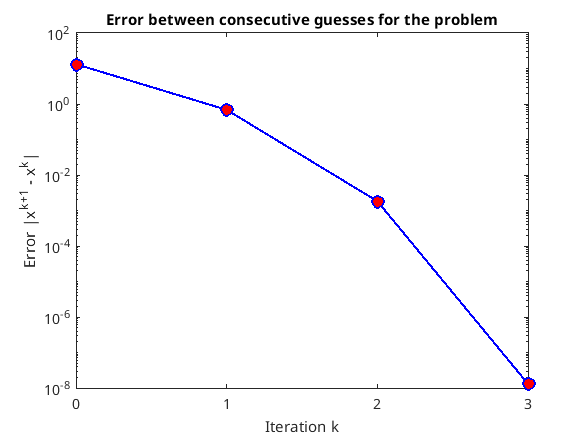

In [3]:
root_estimate = guess_history(end);
errors = abs(guess_history - root_estimate);

iters = 0:length(guess_history)-1;
valid = errors > 0;

figure;
semilogy(iters(valid), errors(valid), "-o", "LineWidth", 1.5, ...
    "MarkerSize", 8, "MarkerFaceColor", "r", "Color", "b");
xticks(0:max(iters));

title("Error between consecutive guesses for the problem");
xlabel("Iteration k");
ylabel("Error |x^{k+1} - x^{k}|");

## Further Discussion

- For this problem, we see that the Newton–Raphson method converges rapidly when the initial guess is close to the real root.
- Since the curve does not have any inflection points near and between the root and the initial guess, we do not observe any oscillations or divergence in the guesses.
- Our criteria of tolerance seems to have been met in 4 iterations, much less than the maximum of 100 iterations.
- This might be improved by keeping a check on the derivative. If $\frac{f(x_n)}{f'(x_n)}$ is very large, which means $f'(x_n)$ is very small, and it keeps increasing, it might be a good sign of non-convergence.

# Question 7

## Problem Statement

Calculate the specific volume of chlorine at $T = 460\ \text{K}$ and $P = 15\ \text{atm}$ using the
**Redlich-Kwong equation of state**:

$$
    P = \frac{RT}{v-b} - \frac{a}{\sqrt{T}\, v(v+b)}
$$

where

$$
    a = \frac{0.4278\, R^2 T_c^{2.5}}{P_c}, \qquad
    b = \frac{0.0867\, R\, T_c}{P_c}
$$

Take the ideal-gas volume as the initial guess, $P_c = 76.1\ \text{atm}, T_c = 417\ \text{K}$.

**Use successive substitution technique for obtaining the root.**


## Analysis

- Successive substitution determines the root of an equation by rearranging it into the form $v = g(v)$, then repeatedly substituting the current guess into $g$ to produce the next guess: $$ v_{n+1} = g(v_n) $$
- To use this on the Redlich-Kwong equation, we rearrange
  $$
      P = \frac{RT}{v-b} - \frac{a}{\sqrt{T}\, v(v+b)}
  $$
  $$
      \implies g(v) = b + \frac{RT}{P + \dfrac{a}{\sqrt{T}\, v(v+b)}}
  $$
- Again, until we reach a stopping criteria, we keep updating the guess with the above formula.
    - If the criteria is a maximum number of iterations, we stop after that many iterations.
    - If the criteria is a tolerance factor, we stop when the difference between two consecutive guesses is less than the tolerance factor: $$ |v_{n+1} - v_n| < \epsilon $$

\newpage

## Algorithm

- **Step 01.** **START**
- **Step 02.** Inputs:

| Variable   | Description                        |
| ---------- | ------------------------------------ |
| $g$        | Function whose root is required |
| $v^0$      | Initial guess                       |
| $k_max$    | Maximum iterations                  |
| $\epsilon$ | Tolerance                           |

- **Step 03.** Initialize:

| Variable    | Description |
| ----------- | ----------- |
| $k$         | $1$         |
| $v^{(k)}$   | $v^0$       |
| $v^{(k+1)}$ | $\infty$    |

- **Step 04.** Repeat until $k \ge k_{\max}$ or $\|v^{(k+1)} - v^{(k)}\| < \epsilon$:
  - **Step 05.** Update current_guess $v^{(k)} = v^{(k+1)}$
  - **Step 06.** Update $v^{(k+1)}$ using the formula:
    $$
        v^{(k+1)} = g\!\left(v^{(k)}\right)
    $$
  - **Step 07.** Increment iteration_count $k = k + 1$
- **Step 08.** End repeat {**Step 04**}
- **Step 09.** Output: Final guess $v^{(k+1)}$
- **Step 10.** **STOP**

## Implementation

In [ ]:
%%file successivesubstitution.m
function [final_guess, converged, guess_history] = ...
    successivesubstitution(g, x0, epsilon, k_max) %#ok<FNDEF>

% @parameter g: function whose root is required
% @parameter x0: initial guess
% @parameter epsilon: tolerance factor for convergence
% @parameter k_max: maximum number of iterations

% @return final_guess: final guess vector after convergence
% @return converged: shows if convergence was achieved
% @return guess_history: history of guesses

if nargin < 4; k_max = 100; end
if nargin < 3; epsilon = 1e-6; end

k = 1; current_guess = x0; new_guess = inf;
guess_history = zeros(k_max, 1);
guess_history(1) = x0;

convergence_criteria_met = @(current_guess, new_guess) ...
    abs(new_guess - current_guess) < epsilon;
stopping_criteria_met = @(iter, current_guess, new_guess) ...
    iter >= k_max || convergence_criteria_met(current_guess, new_guess);

while ~stopping_criteria_met(k, current_guess, new_guess)
    if k > 1; current_guess = new_guess; end

    new_guess = g(current_guess);
    fprintf("(%d) v: %.6f, g(v) - v: %.6f\n", k, current_guess, ...
        current_guess - g(current_guess));

    k = k + 1;
    guess_history(k) = new_guess;
end % end iterating with guess in kth place

final_guess = new_guess;
converged = convergence_criteria_met(current_guess, new_guess);
guess_history = guess_history(1:k);

end

## Results

We use this implementation on the same data as Question 5, since the problem statement is identical apart from the solution technique. The initial data given in the problem statement is stored in the same input file as before:

```yaml
R: 8.314 m^{3}.Pa.K^{-1}.mol^{-1}
T: 460 K
P: 15 atm
T_{0}: 417 K
P_{0}: 76.1 atm
```

In [5]:
fprintf("--- INPUT ---\n");
file = fopen("input.txt", "r");
while ~feof(file); line = fgetl(file);
    tokens = regexp(line, "^([A-Za-z0-9_{}]+):\s*([\d.-]+)", "tokens");
    if ~isempty(tokens)
        value = str2double(tokens{1}{2});
        switch tokens{1}{1}
            case 'R', R = value;
            case 'T', T = value;
            case 'P', P = value;
            case 'T_{0}', T0 = value;
            case 'P_{0}', P0 = value;
        end
    end
end; fclose(file);

a = 0.4278 * R^2 * T0^2.5 / P0;
b = 0.0867 * R * T0 / P0;
v0 = R * T / P;
display_input = table(R, T, P, T0, P0, a, b, v0, ...
    VariableNames={'R', 'T', 'P', 'T_i', 'P_i', 'a', 'b', 'v_i'});
disp(display_input);

g = @(v) b + (R * T) ./ (P + a ./ (sqrt(T) .* v .* (v + b)));

fprintf("--- OUTPUT ---\n");
[final_guess, converged, guess_history] = successivesubstitution(g, v0);
fprintf("\nFinal guess: %.6f\n", final_guess);
fprintf("Converged: %s\n", string(converged));

--- INPUT ---
      R       T     P     T_i    P_i         a           b        v_i  
    _____    ___    __    ___    ____    __________    ______    ______

    8.314    460    15    417    76.1    1.3798e+06    3.9498    254.96

--- OUTPUT ---
(1) v: 254.962667, g(v) - v: 11.604630
(2) v: 243.358036, g(v) - v: 1.406193
(3) v: 241.951843, g(v) - v: 0.182939
(4) v: 241.768904, g(v) - v: 0.024012
(5) v: 241.744892, g(v) - v: 0.003155
(6) v: 241.741737, g(v) - v: 0.000415
(7) v: 241.741322, g(v) - v: 0.000055
(8) v: 241.741268, g(v) - v: 0.000007
(9) v: 241.741261, g(v) - v: 0.000001

Final guess: 241.741260
Converged: true


## Graph

We can visualize how quickly the successive substitution method converges to the root by plotting the difference between two consecutive guesses against the number of iterations.

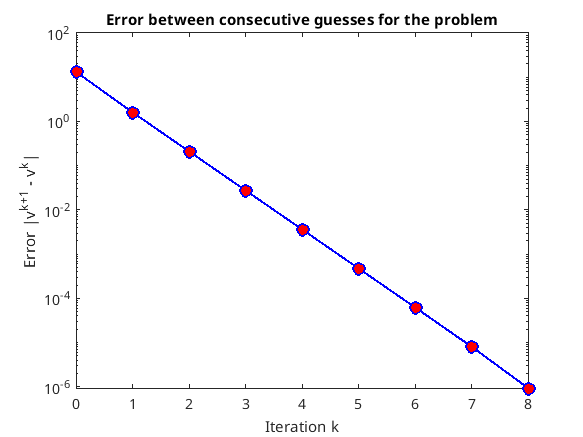

In [6]:
root_estimate = guess_history(end);
errors = abs(guess_history - root_estimate);

iters = 0:length(guess_history)-1;
valid = errors > 0;

figure;
semilogy(iters(valid), errors(valid), "-o", "LineWidth", 1.5, ...
    "MarkerSize", 8, "MarkerFaceColor", "r", "Color", "b");
xticks(0:max(iters));

title("Error between consecutive guesses for the problem");
xlabel("Iteration k");
ylabel("Error |v^{k+1} - v^{k}|");

## Further Discussion

- Both the questions being same, we should get the answers to agree closely, within the tolerance $\epsilon$.
- The key difference is the *rate* of convergence: successive substitution here converges linearly, so it generally needs more iterations than Newton-Raphson's quadratic convergence to reach the same tolerance $\epsilon$.
- The semilog error plot reflects this, rather than the sharply steepening drop seen in the Newton-Raphson case, the error here decreases at a roughly constant rate per iteration, i.e. a straight line on the semilog axes rather than a downward-curving one.
- The trade-off of this method is that it avoids computing $g'(v)$, but its convergence is not always guaranteed. Here it works because the ideal-gas volume $v_0$ is already close to the true root and there is no point of inflection in that neighborhood.